# Simple Predictive Analysis

In [1]:
# import necessary packages

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # for charts/plots
import seaborn as sns             # for charts/plots

# dataset characteristics:
# https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset

from sklearn.datasets import fetch_california_housing  # for dataset
from sklearn.model_selection import train_test_split   # for training/testing model
from sklearn.linear_model import LinearRegression      # linear regression
from sklearn.metrics import mean_squared_error, r2_score  # evaluate model's performance

In [2]:
print(sys.version)  # print python version
print(os.environ['CONDA_DEFAULT_ENV'])  # print conda environment

3.9.21 (main, Dec 11 2024, 16:35:24) [MSC v.1929 64 bit (AMD64)]
testenv


In [3]:
# set frame=True ensures returned object has "frame" attribute
# that is, Pandas DataFrame containing both features and target variable (MedHouseVal)

housing = fetch_california_housing(as_frame=True)  # fetch dataset
type(housing)

sklearn.utils._bunch.Bunch

In [4]:
# dataset is Bunch object with "frame" attribute (i.e., DataFrame)

df = housing.frame
type(df)

pandas.core.frame.DataFrame

In [8]:
# display column names
df.columns

### Notes

# MedInc: Median house income  
# HouseAge: Median house age in block group  
# AveRooms: Average number of rooms per household  
# AveBedrms: Average number of bedrooms per household  
# Population: Block group population  
# AveOccup: Average number of household members  
# Latitude: Block group latitude  
# Longitude: Block group longitude  
# MedHouseVal: Median house value

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [10]:
# first 5 records
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [9]:
# attribute metadata
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [11]:
# rows/cols
df.shape

(20640, 9)

In [12]:
# detect missing values
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [13]:
# list feature types
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

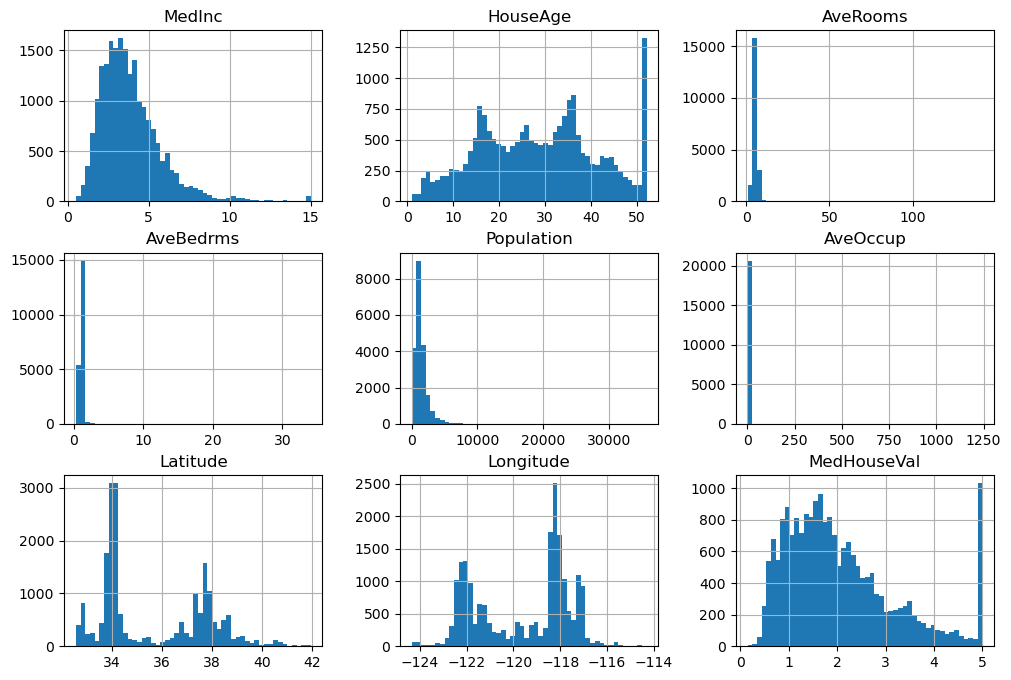

In [15]:
# histogram distribution of all features

df.hist(bins=50, figsize=(12,8))
plt.show()

# Note: y-axis feature values; x-axis: number of feature value occurrences
# Note: features distributed on different scales (permits same sized images); though, x- and y-axis value vary

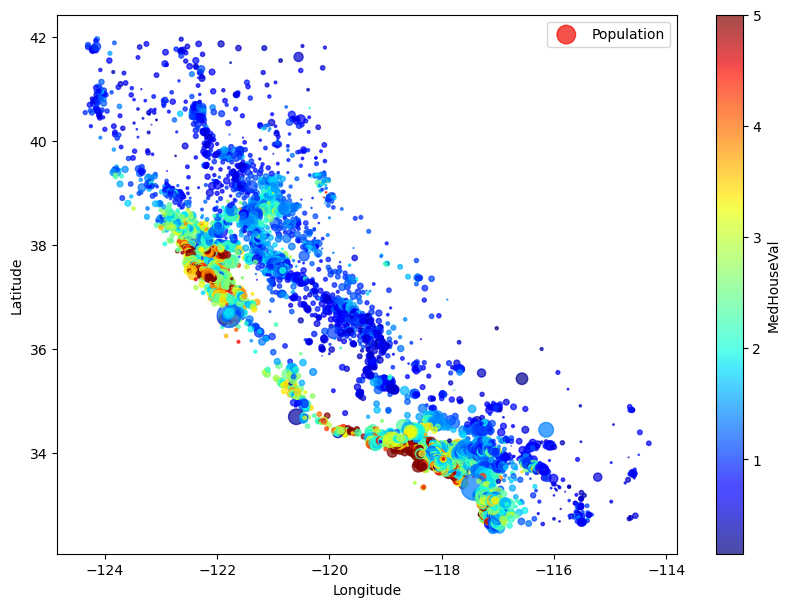

In [16]:
# Plot housing values based on location (latitude / longitude)

# Scatter plot also called bubble chart.

# Legend only indicates population size, colorbar indicates median household income.

df.plot(kind="scatter",
        x="Longitude",
        y="Latitude",
        c="MedHouseVal",
        cmap="jet",
        colorbar=True,
        legend=True,
        sharex=False,
        figsize=(10,7),
        s=df["Population"]/100,
        label="Population",
        alpha=0.7)

plt.show()

# Notes:
# houses near body of water appear higher-valued (though, not necessarily)
# houses in high population areas also more valuable (again, not necessarily, particularly, away from body of water
# outliers


In [17]:
# display attribute correlations
df.corr(numeric_only=True)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [18]:
# display correlation of features against "MedHouseVal"

corr = df.corr()

corr["MedHouseVal"].sort_values(ascending=True)

Latitude      -0.144160
AveBedrms     -0.046701
Longitude     -0.045967
Population    -0.024650
AveOccup      -0.023737
HouseAge       0.105623
AveRooms       0.151948
MedInc         0.688075
MedHouseVal    1.000000
Name: MedHouseVal, dtype: float64

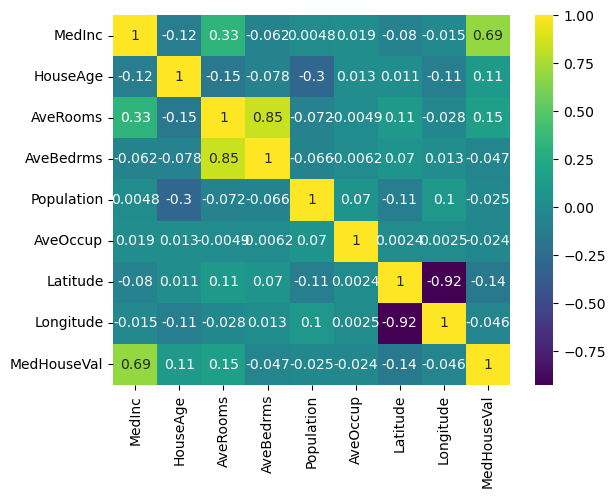

In [19]:
# visually display correlations using seaborn heatmap

sns.heatmap(df.corr(), cmap="viridis", annot=True)

plt.show()

In [20]:
# Split dataset into X and y variables
X = df[['MedInc']]   # top feature
y = df['MedHouseVal'] #target attribute

In [21]:
# display feature values

X

,MedInc
0,8.3252
1,8.3014
2,7.2574
3,5.6431
4,3.8462
...,...
20635,1.5603
20636,2.5568
20637,1.7000
20638,1.8672


In [22]:
# display target attribute values

y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [24]:
# split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=100)

In [25]:
# create linear regression model and train it

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [26]:
# make predictions

predictions = model.predict(X_test)

In [27]:
# evaluate model performance

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.2f}")

MSE: 0.68
R2: 0.49
